In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [2]:
!pip install -q kaggle

In [3]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown


In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# Generators for loading large dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)
test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
# Normalizing the images
def process(image,label):
  image=tf.cast(image/255. , tf.float32)
  return image,label
train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [9]:
# Creating custom CNN Model
model = Sequential()

model.add((Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3))))
model.add(BatchNormalization())
model.add((MaxPooling2D(pool_size=(2,2),strides=2,padding='valid')))

model.add((Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu')))
model.add(BatchNormalization())
model.add((MaxPooling2D(pool_size=(2,2),strides=2,padding='valid')))

model.add((Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu')))
model.add(BatchNormalization())
model.add((MaxPooling2D(pool_size=(2,2),strides=2,padding='valid')))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True,verbose=1)

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
hist = model.fit(train_ds,epochs=10,validation_data=test_ds,callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 83ms/step - accuracy: 0.5876 - loss: 1.8672 - val_accuracy: 0.5488 - val_loss: 0.7066
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 84ms/step - accuracy: 0.7049 - loss: 0.5707 - val_accuracy: 0.7480 - val_loss: 0.4960
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7793 - loss: 0.4616 - val_accuracy: 0.7790 - val_loss: 0.4803
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 77ms/step - accuracy: 0.8131 - loss: 0.3989 - val_accuracy: 0.7988 - val_loss: 0.4446
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8144 - loss: 0.4185 - val_accuracy: 0.7638 - val_loss: 0.5924
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.8662 - loss: 0.3167 - val_accuracy: 0.8274 - val_loss: 0.4434
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9076 - loss: 0.2264 - val_accuracy: 0.7450 - val_loss: 0.7104
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.9385 - loss: 0.1733 - 

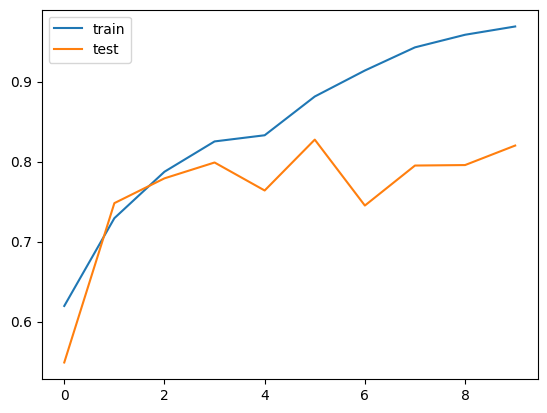

In [14]:
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'],label='train')
plt.plot(hist.history['val_accuracy'],label='test')
plt.legend()
plt.show()

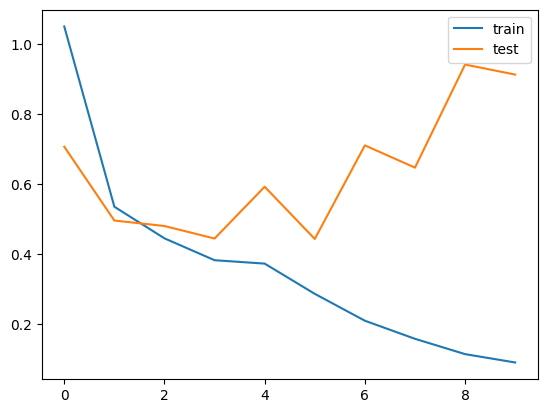

In [15]:
plt.plot(hist.history['loss'],label='train')
plt.plot(hist.history['val_loss'],label='test')
plt.legend()
plt.show()

In [16]:
# Methods to reduce overfitting :
# 1. Data Augmentation
# 2. BatchNormalization
# 3. Dropout, EarlyStopping
# 4. L1/L2 Regularization
# 5. Reduce complexity
# 6. Add more data

img1 (3505, 5257, 3)


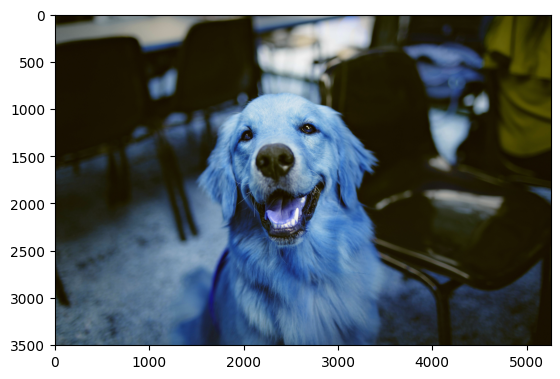

In [30]:
import cv2
test_img_1=cv2.imread('/content/dog.jpg')
plt.imshow(test_img_1)
print("img1",test_img_1.shape)

img2 (360, 540, 3)


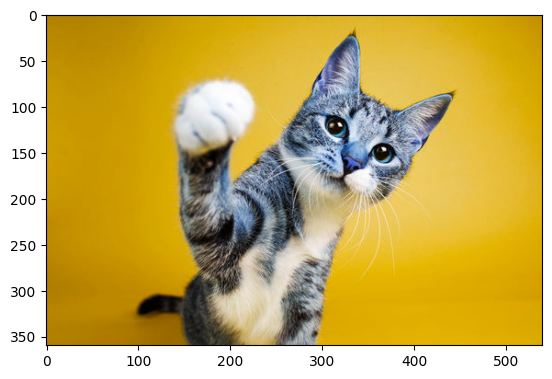

In [31]:
test_img_2=cv2.imread('/content/cat.jpg')
plt.imshow(test_img_2)
print("img2",test_img_2.shape)

In [33]:
# Resize the image to the desired dimensions
test_img_1 = cv2.resize(test_img_1, (256, 256))
test_input_1 = test_img_1.reshape((1,256,256,3))
print(model.predict(test_input_1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[1.]]


In [34]:
# Poor performance
# test_img_2 = cv2.resize(test_img_2, (256, 256))
# test_input_2 = test_img_2.reshape((1,256,256,3))
# print(model.predict(test_input_1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[1.]]


In [25]:
# 1. [Batch Norm, Dropout] accuracy: 0.9486 - loss: 0.1344 - val_accuracy: 0.8202 - val_loss: 0.6937
# 2. [Batch Norm, Dropout, Early stopping] accuracy: 0.9802 - loss: 0.0586 - val_accuracy: 0.8234 - val_loss: 0.8932
# 3.              [same]                   accuracy: 0.9609 - loss: 0.1116 - val_accuracy: 0.8200 - val_loss: 0.9124